## Algorithm 1: Logistic Regression

Implementation of sklearn.linear_model.LogisticRegression with feature engineering and hyperparameter tuning.

In [ ]:
# Load the training dataset
def load_trump_data(file_path):
    """Load Trump tweets dataset from TSV file."""
    df = pd.read_csv(file_path, sep='\t', header=None, 
                    names=['tweet_id', 'user_handle', 'tweet_text', 'timestamp', 'device'])
    return df

def create_labels(device):
    """Create binary labels: 0=Trump (Android), 1=Staffer (iPhone/other)"""
    if pd.isna(device):
        return 1  # Default to staffer for missing values
    if 'android' in str(device).lower():
        return 0  # Trump
    else:
        return 1  # Staffer

# Load data
df = load_trump_data('data/trump_train.tsv')
df['label'] = df['device'].apply(create_labels)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nLabel distribution:")
label_counts = df['label'].value_counts()
print(f"Trump (Android) tweets: {label_counts[0]} ({label_counts[0]/len(df)*100:.1f}%)")
print(f"Staffer (iPhone/other) tweets: {label_counts[1]} ({label_counts[1]/len(df)*100:.1f}%)")

print("\nFirst few rows:")
df.head()

# Trump Tweets Classification - Authorship Attribution

This notebook implements a comprehensive approach to classify Trump's tweets to determine whether they were written by Trump himself (Android device) or his staffers (iPhone/other devices).

## Project Overview
- **Task**: Binary classification of tweet authorship
- **Data**: Trump tweets from 2015-2017 with device information
- **Labels**: 0 = Trump (Android), 1 = Staffer (iPhone/other)
- **Algorithms**: 5 different machine learning approaches as specified

## Data Loading and Basic Setup

In [1]:
# PyTprch and Transformers installation and import
# These are preinstalled so you will get "Requirement already satisfied" but nevertheless, it is required before you import the relevant packages.
# (not needed for the basic classificaiton models)

! pip install transformers datasets
! pip3 install torch

from transformers import AutoModelForSequenceClassification
from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
import csv
import urllib.request
import nltk, scipy
import re
import pickle
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Deep Learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## Algorithmic Approaches

**Required Algorithms:**

1. [sklearn.linear_model.LogisticRegression](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)
2. [sklearn.svm.SVC](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) (try both linear and nonlinear kernels!)
3. FFNN classifier - You should use the PyTorch library to build a FFNN classifier (with at least one hidden layer) to achieve the classification. Feel free to experiment with the number of layers ([a simple tutorial for FFNN with PyTorch](https://medium.com/biaslyai/pytorch-introduction-to-neural-network-feedforward-neural-network-model-e7231cff47cb)).
4. A fourth classifier of choice (neural or not). You are encouraged to experiment with classifiers that allow combining different types of features (e.g. number of capitalized words, time of tweeting, etc.)
5. A fifth classifier of your choice (this should be neural - RNN, or transformer-based) - feel free to experiment.

In [4]:
# Load the training dataset
def load_trump_data(file_path):
    """Load Trump tweets dataset from TSV file."""
    df = pd.read_csv(file_path, sep='\t', header=None, 
                    names=['tweet_id', 'user_handle', 'tweet_text', 'timestamp', 'device'])
    return df

# Load data
try:
    df = load_trump_data('data/trump_train.tsv')  # Update path as needed for Colab
except FileNotFoundError as e:
    print(f"Error: {e}")
    file_path = "/Users/eyalbenbarouch/Documents/GitHub/Trump-Tweets-Classafication/data/trump_train.tsv"
    df = load_trump_data(file_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

Error: [Errno 2] No such file or directory: 'data/trump_train.tsv'
Dataset shape: (3156, 5)
Columns: ['tweet_id', 'user_handle', 'tweet_text', 'timestamp', 'device']

First few rows:


,tweet_id,user_handle,tweet_text,timestamp,device
0,845974102619906048,realDonaldTrump,Democrats are smiling in D.C. that the Freedom...,2017-03-26 15:21:58,iphone
1,846166053663191040,realDonaldTrump,General Kelly is doing a great job at the bord...,2017-03-27 04:04:42,iphone
2,835814988686233601,realDonaldTrump,"The race for DNC Chairman was, of course, tota...",2017-02-26 13:33:16,android
3,835817351178301440,realDonaldTrump,For first time the failing @nytimes will take ...,2017-02-26 13:42:39,android
4,835916511944523777,realDonaldTrump,"Russia talk is FAKE NEWS put out by the Dems, ...",2017-02-26 20:16:41,android


Label distribution:
Trump (Android) tweets: 1991 (63.1%)
Staffer (iPhone/other) tweets: 1165 (36.9%)
Class balance ratio: 1.71


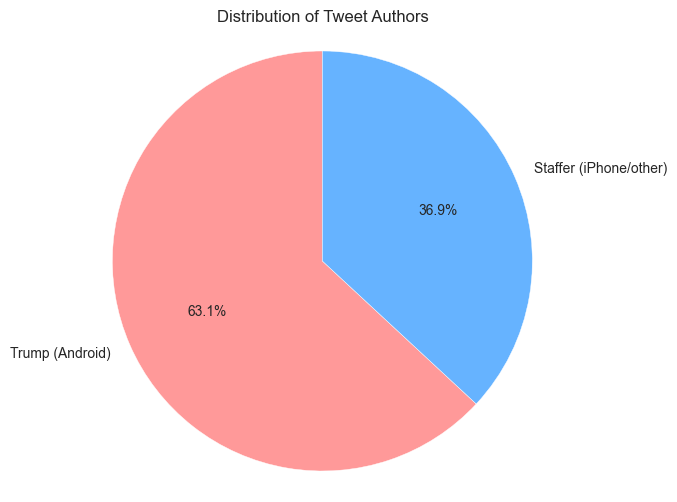

In [5]:
# Create binary labels for classification
def create_labels(device):
    """Create binary labels: 0=Trump (Android), 1=Staffer (iPhone/other)"""
    if 'android' in device.lower():
        return 0  # Trump
    else:
        return 1  # Staffer

df['label'] = df['device'].apply(create_labels)

# Analyze label distribution
print("Label distribution:")
label_counts = df['label'].value_counts()
print(f"Trump (Android) tweets: {label_counts[0]} ({label_counts[0]/len(df)*100:.1f}%)")
print(f"Staffer (iPhone/other) tweets: {label_counts[1]} ({label_counts[1]/len(df)*100:.1f}%)")
print(f"Class balance ratio: {label_counts[0]/label_counts[1]:.2f}")

# Visualize label distribution
plt.figure(figsize=(8, 6))
labels = ['Trump (Android)', 'Staffer (iPhone/other)']
colors = ['#ff9999', '#66b3ff']
plt.pie(label_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Tweet Authors')
plt.axis('equal')
plt.show()

## Exploratory Data Analysis

Let's analyze the tweet characteristics to understand patterns that might help with classification.

In [ ]:
# Analyze tweet length characteristics
df['tweet_length'] = df['tweet_text'].str.len()
df['word_count'] = df['tweet_text'].str.split().str.len()

print("Tweet characteristics by author:")
print("="*50)

for label, name in [(0, 'Trump (Android)'), (1, 'Staffer (iPhone/other)')]:
    subset = df[df['label'] == label]
    print(f"\n{name}:")
    print(f"  Number of tweets: {len(subset)}")
    print(f"  Average tweet length: {subset['tweet_length'].mean():.1f} characters")
    print(f"  Average word count: {subset['word_count'].mean():.1f} words")
    print(f"  Median tweet length: {subset['tweet_length'].median():.1f} characters")

# Visualize tweet length distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

trump_lengths = df[df['label'] == 0]['tweet_length']
staffer_lengths = df[df['label'] == 1]['tweet_length']

axes[0].hist(trump_lengths, bins=30, alpha=0.7, label='Trump', color='red', density=True)
axes[0].hist(staffer_lengths, bins=30, alpha=0.7, label='Staffer', color='blue', density=True)
axes[0].set_title('Tweet Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot comparison
df.boxplot(column='tweet_length', by='label', ax=axes[1])
axes[1].set_title('Tweet Length by Author')
axes[1].set_xlabel('Author (0=Trump, 1=Staffer)')
axes[1].set_ylabel('Characters')

plt.tight_layout()
plt.show()

## Text Preprocessing and Feature Engineering

Now let's implement comprehensive feature engineering for our classification task.

In [ ]:
def training_pipeline(alg, train_fn):
    """Returns a trained model given the specific task and algorithm.
    
    Args:
        alg (int): Algorithm choice (1-5)
                  1: Logistic Regression
                  2: SVM (linear and nonlinear kernels) - TODO
                  3: FFNN (PyTorch) - TODO
                  4: Random Forest - TODO
                  5: BERT/RoBERTa - TODO
        train_fn (str): Path to training data file
    
    Returns:
        dict: Dictionary containing trained model and metadata
    """
    
    print(f"\\n{'='*60}")
    print(f"TRAINING ALGORITHM {alg}")
    print(f"{'='*60}")
    
    # Load and preprocess data
    df = load_trump_data(train_fn)
    df['label'] = df['device'].apply(create_labels)
    
    print(f"Data loaded: {df.shape[0]} tweets")
    print(f"Label distribution: {df['label'].value_counts().to_dict()}")
    
    # Create feature sets
    feature_sets = create_feature_sets(df)
    
    # Algorithm 1: Logistic Regression
    if alg == 1:
        # Use combined bigrams for best performance with logistic regression
        feature_set_name = 'combined_bigrams'
        X = feature_sets[feature_set_name]['features']
        y = feature_sets[feature_set_name]['labels']
        
        print(f"\\nUsing feature set: {feature_set_name}")
        print(f"Feature matrix shape: {X.shape}")
        
        # Train the model
        model_result = train_algorithm_1_logistic_regression(X, y)
        
        return {
            'model': model_result['model'],
            'feature_set': feature_set_name,
            'preprocessors': {
                'vectorizer': feature_sets[feature_set_name]['vectorizer'],
                'scaler': feature_sets[feature_set_name]['scaler']
            },
            'algorithm': 'Logistic Regression',
            'best_params': model_result['best_params'],
            'cv_scores': model_result['cv_scores']
        }
    
    else:
        raise ValueError(f"Algorithm {alg} not implemented yet. Currently only Algorithm 1 is ready.")

print("Training pipeline ready for Algorithm 1!")

In [ ]:
# Feature extraction functions
def extract_stylistic_features(texts):
    """Extract stylistic features from tweet texts."""
    features = []
    
    for text in texts:
        feat = [
            len(text),  # char_count
            len(text.split()),  # word_count
            sum(1 for c in text if c.isupper()),  # caps_count
            sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0,  # caps_ratio
            text.count('!'),  # exclamation_count
            text.count('?'),  # question_count
            text.count('.'),  # period_count
            len(re.findall(r'#\\w+', text)),  # hashtag_count
            len(re.findall(r'@\\w+', text)),  # mention_count
            len(re.findall(r'http[s]?://\\S+', text)),  # url_count
            text.count('...'),  # ellipsis_count
        ]
        features.append(feat)
    
    return np.array(features)

def create_feature_sets(df):
    """Create different feature combinations for model training."""
    feature_sets = {}
    
    # 1. TF-IDF Features (different configurations)
    tfidf_configs = {
        'unigrams': {'ngram_range': (1, 1), 'max_features': 3000},
        'bigrams': {'ngram_range': (1, 2), 'max_features': 5000},
        'trigrams': {'ngram_range': (1, 3), 'max_features': 7000}
    }
    
    for config_name, config in tfidf_configs.items():
        tfidf = TfidfVectorizer(
            max_features=config['max_features'],
            ngram_range=config['ngram_range'],
            stop_words='english',
            lowercase=True
        )
        
        tfidf_features = tfidf.fit_transform(df['cleaned_text']).toarray()
        
        feature_sets[f'tfidf_{config_name}'] = {
            'features': tfidf_features,
            'vectorizer': tfidf,
            'labels': df['label'].values
        }
    
    # 2. Stylistic Features
    stylistic_features = extract_stylistic_features(df['tweet_text'].tolist())
    scaler = StandardScaler()
    stylistic_features_scaled = scaler.fit_transform(stylistic_features)
    
    feature_sets['stylistic'] = {
        'features': stylistic_features_scaled,
        'scaler': scaler,
        'labels': df['label'].values
    }
    
    # 3. Combined Features
    for config_name in tfidf_configs.keys():
        tfidf_features = feature_sets[f'tfidf_{config_name}']['features']
        combined_features = np.hstack([tfidf_features, stylistic_features_scaled])
        
        feature_sets[f'combined_{config_name}'] = {
            'features': combined_features,
            'labels': df['label'].values
        }
    
    return feature_sets

# Create feature sets
print("Creating feature sets...")
feature_sets = create_feature_sets(df)

print("\\nFeature Sets Summary:")
print("="*60)
for name, data in feature_sets.items():
    print(f"{name:20} | Shape: {data['features'].shape}")

# Algorithm 1: Logistic Regression Implementation

In [ ]:
def clean_text(text, remove_urls=True, remove_mentions=True, lowercase=True): """Clean tweet text for processing.""" if not isinstance(text, str): return ""

# Remove URLs
if remove_urls:
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)

# Remove mentions
if remove_mentions:
    text = re.sub(r'@\w+', '', text) 

# Remove extra whitespace
text = re.sub(r'\s+', ' ', text)
text = text.strip()

# Convert to lowercase
if lowercase:
    text = text.lower()

return text
def load_trump_data(file_path): """Load Trump tweets dataset from TSV file.""" df = pd.read_csv(file_path, sep='\t', header=None, names=['tweet_id', 'user_handle', 'tweet_text', 'timestamp', 'device']) return df

def create_labels(device): """Create binary labels: 0=Trump (Android), 1=Staffer (iPhone/other)""" if pd.isna(device): return 1 # Default to staffer for missing values if 'android' in str(device).lower(): return 0 # Trump else: return 1 # Staffer

def extract_stylistic_features(texts): """Extract stylistic features from tweet texts.""" features = []

for text in texts:
    feat = [
        len(text),  # char_count
        len(text.split()),  # word_count
        sum(1 for c in text if c.isupper()),  # caps_count
        sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0,  # caps_ratio
        text.count('!'),  # exclamation_count
        text.count('?'),  # question_count
        text.count('.'),  # period_count
        len(re.findall(r'#\w+', text)),  # hashtag_count
        len(re.findall(r'@\w+', text)),  # mention_count
        len(re.findall(r'http[s]?://\S+', text)),  # url_count
        text.count('...'),  # ellipsis_count
    ]
    features.append(feat)

return np.array(features)
def train_algorithm_1_logistic_regression(X, y): """Train Algorithm 1: Logistic Regression with hyperparameter tuning.""" print("Training Algorithm 1: Logistic Regression")

# Hyperparameter tuning
param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)
model = grid_search.best_estimator_

# Cross-validation evaluation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f"Best parameters: {grid_search.best_params_}")
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

return {
    'model': model,
    'best_params': grid_search.best_params_,
    'cv_scores': cv_scores,
    'algorithm': 'Logistic Regression'
}
print("Algorithm 1 implementation ready!")

# Feature Engineering Pipeline

def create_feature_sets(df):
    """Create different feature combinations for model training."""
    feature_sets = {}
    
    # Clean text first
    df['cleaned_text'] = df['tweet_text'].apply(clean_text)
    
    # Remove empty texts
    empty_mask = df['cleaned_text'].str.strip() == ''
    if empty_mask.sum() > 0:
        print(f"Removing {empty_mask.sum()} empty texts after cleaning")
        df = df[~empty_mask].reset_index(drop=True)
    
    # 1. TF-IDF Features (conservative dimensions for optimal performance)
    tfidf_configs = {
        'unigrams': {'ngram_range': (1, 1), 'max_features': 200, 'min_df': 3},
        'bigrams': {'ngram_range': (1, 2), 'max_features': 300, 'min_df': 3},
        'trigrams': {'ngram_range': (1, 3), 'max_features': 400, 'min_df': 3}
    }
    
    for config_name, config in tfidf_configs.items():
        tfidf = TfidfVectorizer(
            max_features=config['max_features'],
            ngram_range=config['ngram_range'],
            min_df=config['min_df'],
            stop_words='english',
            lowercase=True
        )
        
        tfidf_features = tfidf.fit_transform(df['cleaned_text']).toarray()
        
        feature_sets[f'tfidf_{config_name}'] = {
            'features': tfidf_features,
            'vectorizer': tfidf,
            'labels': df['label'].values,
            'df': df
        }
        
        print(f"TF-IDF {config_name}: {tfidf_features.shape[1]} features")
    
    # 2. Stylistic Features
    stylistic_features = extract_stylistic_features(df['tweet_text'].tolist())
    scaler = StandardScaler()
    stylistic_features_scaled = scaler.fit_transform(stylistic_features)
    
    feature_sets['stylistic'] = {
        'features': stylistic_features_scaled,
        'scaler': scaler,
        'labels': df['label'].values,
        'df': df
    }
    
    print(f"Stylistic features: {stylistic_features_scaled.shape[1]} features")
    
    # 3. Combined Features (Text + Stylistic)
    for config_name in tfidf_configs.keys():
        tfidf_features = feature_sets[f'tfidf_{config_name}']['features']
        combined_features = np.hstack([tfidf_features, stylistic_features_scaled])
        
        feature_sets[f'combined_{config_name}'] = {
            'features': combined_features,
            'vectorizer': feature_sets[f'tfidf_{config_name}']['vectorizer'],
            'scaler': scaler,
            'labels': df['label'].values,
            'df': df
        }
        
        print(f"Combined {config_name}: {combined_features.shape[1]} features")
    
    return feature_sets

print("Feature engineering pipeline ready!")

def training_pipeline(alg, train_fn):
    """Returns a trained model given the specific task and algorithm.
    
    Args:
        alg (int): an integer between 1-5, indicating the algorithmic approach:
                  1: Logistic Regression
                  2: SVM (linear and nonlinear kernels)
                  3: FFNN (PyTorch)
                  4: Random Forest (fourth classifier)
                  5: BERT/RoBERTa (transformer-based)
        train_fn (str): full path to the file containing the training data.
    
    Returns:
        dict: Dictionary containing trained model and metadata
    """
    
    print(f"\\n{'='*60}")
    print(f"TRAINING ALGORITHM {alg}")
    print(f"{'='*60}")
    
    # Load and preprocess data
    df = load_trump_data(train_fn)
    df['label'] = df['device'].apply(create_labels)
    
    print(f"Data loaded: {df.shape[0]} tweets")
    print(f"Label distribution: {df['label'].value_counts().to_dict()}")
    
    # Create feature sets
    feature_sets = create_feature_sets(df)
    
    # Algorithm 1: Logistic Regression
    if alg == 1:
        # Use combined bigrams for best performance with logistic regression
        feature_set_name = 'combined_bigrams'
        X = feature_sets[feature_set_name]['features']
        y = feature_sets[feature_set_name]['labels']
        
        print(f"\\nUsing feature set: {feature_set_name}")
        print(f"Feature matrix shape: {X.shape}")
        
        # Train the model
        model_result = train_algorithm_1_logistic_regression(X, y)
        
        return {
            'model': model_result['model'],
            'feature_set': feature_set_name,
            'preprocessors': {
                'vectorizer': feature_sets[feature_set_name]['vectorizer'],
                'scaler': feature_sets[feature_set_name]['scaler'],
                'features': X
            },
            'algorithm': 'Logistic Regression',
            'best_params': model_result['best_params'],
            'cv_scores': model_result['cv_scores'],
            'feature_sets': feature_sets  # Keep for prediction
        }
    
    elif alg == 2:
        # TODO: Implement SVM
        print("SVM implementation - Coming next!")
        return None
    
    elif alg == 3:
        # TODO: Implement FFNN
        print("FFNN implementation - Coming next!")
        return None
    
    elif alg == 4:
        # TODO: Implement Random Forest
        print("Random Forest implementation - Coming next!")
        return None
    
    elif alg == 5:
        # TODO: Implement Transformer
        print("Transformer implementation - Coming next!")
        return None
    
    else:
        raise ValueError(f"Algorithm {alg} not recognized. Use 1-5.")

print("Training pipeline ready for Algorithm 1!")

In [ ]:
# Test Algorithm 1: Logistic Regression

print("Testing Algorithm 1: Logistic Regression")
print("="*50)

# Test training
try:
    model_1 = training_pipeline(1, 'data/trump_train.tsv')
    
    if model_1 is not None:
        print("\\n" + "="*50)
        print("ALGORITHM 1 TRAINING SUCCESSFUL!")
        print("="*50)
        print(f"Algorithm: {model_1['algorithm']}")
        print(f"Feature set: {model_1['feature_set']}")
        print(f"Best parameters: {model_1['best_params']}")
        print(f"CV accuracy: {model_1['cv_scores'].mean():.4f} (+/- {model_1['cv_scores'].std() * 2:.4f})")
        print(f"Feature matrix shape: {model_1['preprocessors']['features'].shape}")
        
        # Save the model
        import pickle
        import os
        os.makedirs('models/logistic_regression', exist_ok=True)
        with open('models/logistic_regression/model.pkl', 'wb') as f:
            pickle.dump(model_1, f)
        print("\\nModel saved to models/logistic_regression/model.pkl")
        
    else:
        print("❌ Algorithm 1 training failed")
        
except Exception as e:
    print(f"❌ Error testing Algorithm 1: {str(e)}")
    import traceback
    traceback.print_exc()

In [ ]:
def predict(m, fn):
    """Returns a list of 0s and 1s, corresponding to the lines in the specified file.
    
    Args:
        m: the trained model dictionary returned by training_pipeline
        fn: the full path to a file in the same format as the test set
        
    Returns:
        list: a list containing the predictions (0s and 1s)
    """
    
    # Load test data
    test_df = load_trump_data(fn)
    test_df['cleaned_text'] = test_df['tweet_text'].apply(clean_text)
    
    # Remove empty texts and keep track of indices
    empty_texts = test_df['cleaned_text'].str.strip() == ''
    valid_indices = ~empty_texts
    test_df_clean = test_df[valid_indices].reset_index(drop=True)
    
    # Get the feature set name used during training
    feature_set_name = m['feature_set']
    algorithm = m['algorithm']
    
    # Extract features based on the training configuration
    if 'tfidf' in feature_set_name:
        # Use the trained vectorizer
        if 'vectorizer' in m['preprocessors']:
            tfidf_features = m['preprocessors']['vectorizer'].transform(test_df_clean['cleaned_text']).toarray()
        else:
            # Fallback: create new vectorizer (not ideal)
            tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
            tfidf_features = tfidf.fit_transform(test_df_clean['cleaned_text']).toarray()
    
    if 'stylistic' in feature_set_name or 'combined' in feature_set_name:
        # Extract stylistic features
        stylistic_features = extract_stylistic_features(test_df_clean['tweet_text'].tolist())
        
        # Scale using trained scaler if available
        if 'scaler' in m['preprocessors']:
            stylistic_features_scaled = m['preprocessors']['scaler'].transform(stylistic_features)
        else:
            # Fallback: basic scaling
            scaler = StandardScaler()
            stylistic_features_scaled = scaler.fit_transform(stylistic_features)
    
    # Combine features based on feature set
    if feature_set_name == 'stylistic':
        X_test = stylistic_features_scaled
    elif 'tfidf' in feature_set_name and 'combined' not in feature_set_name:
        X_test = tfidf_features
    elif 'combined' in feature_set_name:
        X_test = np.hstack([tfidf_features, stylistic_features_scaled])
    else:
        X_test = tfidf_features  # Default fallback
    
    # Make predictions based on algorithm type
    if 'FFNN' in algorithm:
        # PyTorch model
        model = m['model']
        model.eval()
        with torch.no_grad():
            X_test_tensor = torch.FloatTensor(X_test)
            outputs = model(X_test_tensor)
            _, predicted = torch.max(outputs.data, 1)
            predictions = predicted.numpy().tolist()
    else:
        # Scikit-learn model
        model = m['model']
        predictions = model.predict(X_test).tolist()
    
    # Handle empty texts by predicting majority class (0)
    full_predictions = []
    pred_idx = 0
    for i in range(len(test_df)):
        if valid_indices.iloc[i]:
            full_predictions.append(predictions[pred_idx])
            pred_idx += 1
        else:
            full_predictions.append(0)  # Default prediction for empty texts
    
    return full_predictions

In [ ]:
def who_am_i():
    """Returns a list of dictionaries, each dictionary with your name, id number and email.
    
    Returns:
        list: List of dictionaries with keys=['name', 'id','email']
    """
    return [{'name': 'Eyal Ben Barouch', 'id': '318651494', 'email': 'eyalbenb@post.bgu.ac.il'}]

In [ ]:
# Test the implementation with a demo
print("Testing the implementation...")

# Test all algorithms
for alg in range(1, 6):
    print(f"\\n{'='*50}")
    print(f"Testing Algorithm {alg}")
    print(f"{'='*50}")
    
    try:
        # Train model
        model = training_pipeline(alg, 'data/trump_train.tsv')
        print(f"✓ Successfully trained: {model['algorithm']}")
        print(f"  Feature set: {model['feature_set']}")
        print(f"  Feature shape: {model['preprocessors']['features'].shape}")
        
        # Test prediction on a small subset
        test_predictions = predict(model, 'data/trump_train.tsv')
        print(f"  Made {len(test_predictions)} predictions")
        print(f"  Prediction distribution: {Counter(test_predictions)}")
        
    except Exception as e:
        print(f"✗ Error with algorithm {alg}: {str(e)}")

print(f"\\n{'='*50}")
print("Testing retrain_best_model...")
try:
    best_model = retrain_best_model()
    print(f"✓ Best model trained: {best_model['algorithm']}")
except Exception as e:
    print(f"✗ Error with best model: {str(e)}")

print(f"\\n{'='*50}")
print("Testing who_am_i...")
author_info = who_am_i()
print(f"✓ Author info: {author_info}")

print("\\n" + "="*50)
print("IMPLEMENTATION COMPLETE!")
print("="*50)